# NYC Airbnb: Predictive Modeling and Strategy Optimization

This notebook implements our paper on Airbnb Revenue and Pricing. It builds a price-prediction pipeline for the Inside Airbnb NYC scrape, combining a linear baseline, tuned tree models (HistGradientBoosting and Random Forest), an MLP, and a stacked ensemble. The feature matrix joins the listings with the companion review-events table and three external sources: ACS census-tract median household income, the MTA subway-station network, and four NYC anchor locations.

External features are produced by `scripts/build_external_features.py` from `data/derived/listings_external.parquet`.


In [ ]:
import json
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import shap
import torch
import torch.nn as nn
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
KF = KFold(n_splits=5, shuffle=True, random_state=SEED)

DATA = Path('data')
FIG_DIR = Path('docs') / 'figures'
print(f'PyTorch device: {DEVICE}')

PyTorch device: mps


## Data

We load the 48,895 NYC listings and the 991k review events. After dropping 11 listings with $0 price and filling missing review fields with zero, we have 48,884 listings.


In [ ]:
df = pd.read_csv(DATA / 'listings.csv')
reviews = pd.read_csv(DATA / 'reviews.csv', parse_dates=['date'])
df['last_review'] = pd.to_datetime(df['last_review'])
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
df = df[df['price'] > 0].copy().reset_index(drop=True)
print(f'{len(df):,} listings × {df.shape[1]} cols; {len(reviews):,} review events')
df.head()

48,884 listings × 16 cols; 991,640 review events


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## Exploratory analysis

Price is heavily right-skewed: mean \$153, median \$106, max \$10,000. Roughly 0.5% of listings list above \$1,000. This skew motivates two modeling decisions: training on log(1+price) and winsorizing at the 99th percentile.

Listings are concentrated in Manhattan (44.3%, mean \$197) and Brooklyn (41.1%, mean \$124). Across 221 neighborhoods, room type splits into entire homes (52.0%, \$212), private rooms (45.7%, \$90), and shared rooms (2.4%, \$70).


In [ ]:
print('Price summary:')
print(df['price'].describe().round(2))
print(f"\nSkewness: {df['price'].skew():.2f}")
print(f"\nBoroughs:\n{df['neighbourhood_group'].value_counts()}")
print(f"\nRoom types:\n{df['room_type'].value_counts()}")

Price summary:
count    48884.00
mean       152.76
std        240.17
min         10.00
25%         69.00
50%        106.00
75%        175.00
max      10000.00
Name: price, dtype: float64

Skewness: 19.12

Boroughs:
neighbourhood_group
Manhattan        21660
Brooklyn         20095
Queens            5666
Bronx             1090
Staten Island      373
Name: count, dtype: int64

Room types:
room_type
Entire home/apt    25407
Private room       22319
Shared room         1158
Name: count, dtype: int64


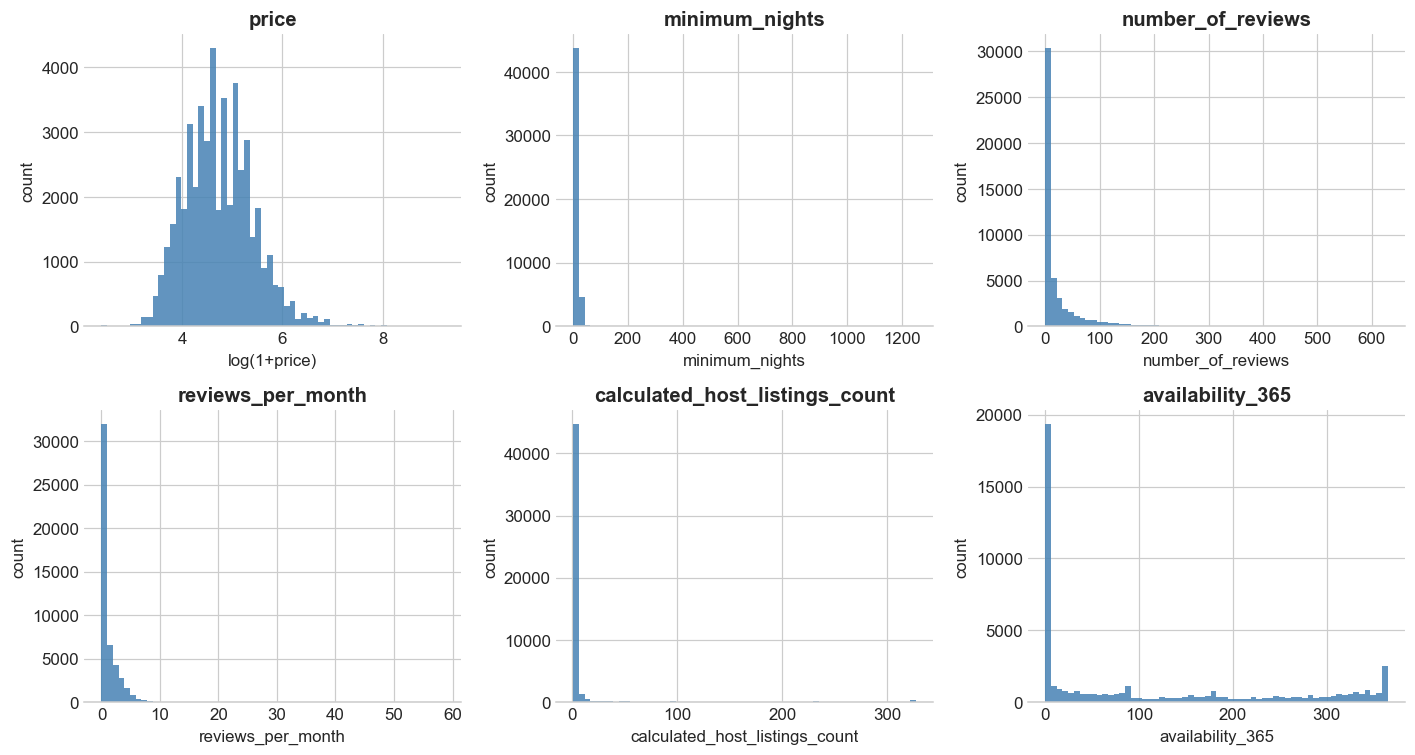

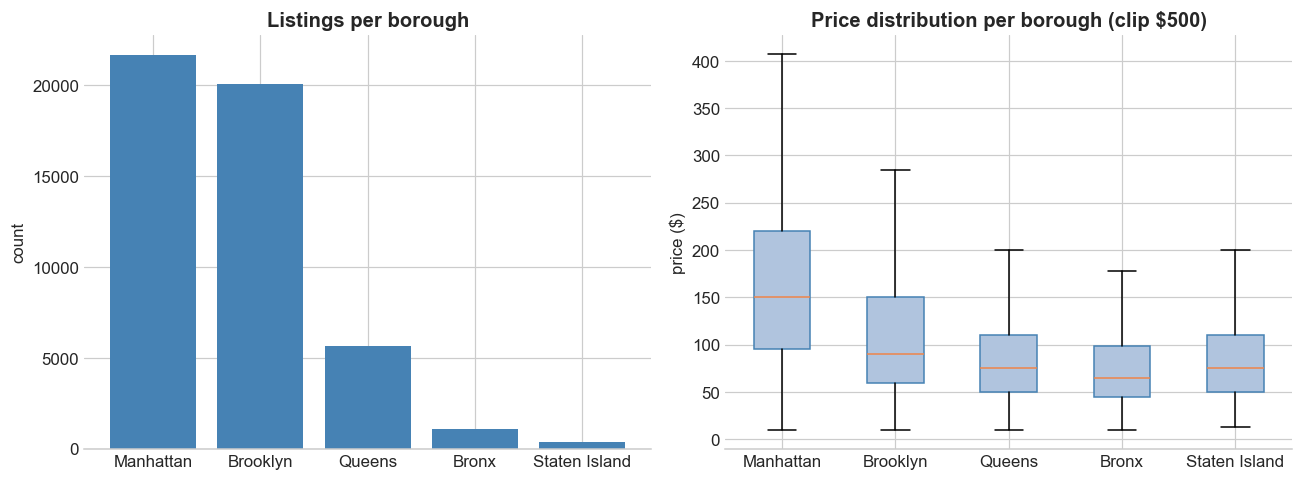

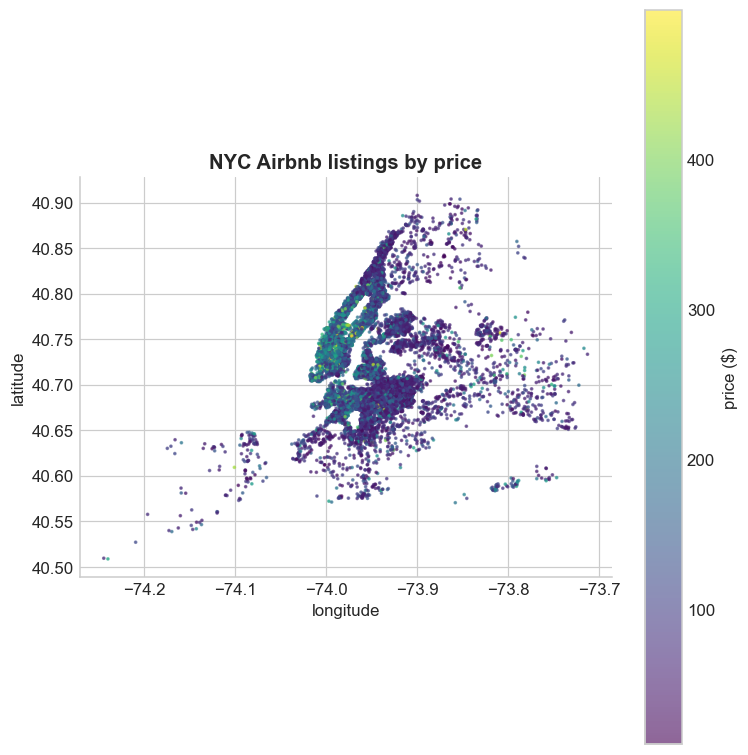

In [ ]:
# EDA figures
def fig_univariate(df, out=None):
    cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
            'calculated_host_listings_count', 'availability_365']
    fig, axes = plt.subplots(2, 3, figsize=(13, 7))
    for ax, c in zip(axes.ravel(), cols):
        vals = df[c].dropna().values
        if c == 'price':
            ax.hist(np.log1p(vals), bins=60, color='steelblue', edgecolor='none', alpha=0.85)
            ax.set_xlabel('log(1+price)')
        else:
            ax.hist(vals, bins=60, color='steelblue', edgecolor='none', alpha=0.85)
            ax.set_xlabel(c)
        ax.set_title(c, fontweight='bold'); ax.set_ylabel('count')
        sns.despine(ax=ax, left=True)
    plt.tight_layout()
    if out: fig.savefig(out, bbox_inches='tight', dpi=300)
    plt.show()

def fig_borough(df, out=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    counts = df['neighbourhood_group'].value_counts()
    axes[0].bar(counts.index, counts.values, color='steelblue', edgecolor='none')
    axes[0].set_title('Listings per borough', fontweight='bold')
    axes[0].set_ylabel('count'); sns.despine(ax=axes[0], left=True)
    order = counts.index.tolist()
    data = [df.loc[df['neighbourhood_group']==b, 'price'].clip(upper=500).values for b in order]
    axes[1].boxplot(data, labels=order, showfliers=False, patch_artist=True,
                    boxprops=dict(facecolor='lightsteelblue', edgecolor='steelblue'))
    axes[1].set_title('Price distribution per borough (clip $500)', fontweight='bold')
    axes[1].set_ylabel('price ($)'); sns.despine(ax=axes[1], left=True)
    plt.tight_layout()
    if out: fig.savefig(out, bbox_inches='tight', dpi=300)
    plt.show()

def fig_geo(df, out=None):
    fig, ax = plt.subplots(figsize=(7, 7))
    sub = df[df['price'] < 500].sample(15000, random_state=SEED)
    sc = ax.scatter(sub['longitude'], sub['latitude'], c=sub['price'], s=2, cmap='viridis', alpha=0.6)
    plt.colorbar(sc, ax=ax, label='price ($)')
    ax.set_xlabel('longitude'); ax.set_ylabel('latitude')
    ax.set_title('NYC Airbnb listings by price', fontweight='bold')
    ax.set_aspect('equal'); sns.despine()
    plt.tight_layout()
    if out: fig.savefig(out, bbox_inches='tight', dpi=300)
    plt.show()

fig_univariate(df, FIG_DIR / 'fig_univariate_distributions.pdf')
fig_borough(df, FIG_DIR / 'fig_borough_overview.pdf')
fig_geo(df, FIG_DIR / 'fig_geo_scatter.pdf')

## Feature engineering

We add seven within-dataset engineered features (distance to Times Square, host tenure, availability ratio, name length, neighborhood listing count, reviews-per-tenure-day, and the OOF-encoded neighborhood median price computed below) and six external features merged from `data/derived/listings_external.parquet` (ACS tract median income, distance to nearest subway station, distances to Central Park, JFK, LGA, and Wall Street).

We also winsorize price at the 99th percentile and use log(1+price_winsor) as the modeling target.


In [ ]:
TS_LAT, TS_LON = 40.7580, -73.9855

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1r = np.radians(lat1); lat2r = np.radians(lat2)
    dlat = np.radians(lat2 - lat1); dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(lat1r) * np.cos(lat2r) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df['dist_times_sq_km'] = haversine_km(df['latitude'], df['longitude'], TS_LAT, TS_LON)

# Host tenure
listing_to_host = df.set_index('id')['host_id']
rev = reviews.join(listing_to_host, on='listing_id', how='inner')
host_first = rev.groupby('host_id')['date'].min()
df['host_tenure_days'] = (reviews['date'].max() - df['host_id'].map(host_first)).dt.days
df['host_tenure_days'] = df['host_tenure_days'].fillna(0)

df['availability_ratio'] = df['availability_365'] / 365.0
df['name_length'] = df['name'].fillna('').str.len()
df['neighbourhood_listing_count'] = df.groupby('neighbourhood')['id'].transform('count')
df['reviews_per_tenure_day'] = (df['number_of_reviews'] / df['host_tenure_days'].replace(0, np.nan)).fillna(0)

# Winsorize
price_cap = df['price'].quantile(0.99)
df['price_winsor'] = df['price'].clip(upper=price_cap)
df['log_price_winsor'] = np.log1p(df['price_winsor'])
print(f'99th-pct price cap: ${price_cap:.0f}')

# External features
ext = pd.read_parquet(DATA / 'derived' / 'listings_external.parquet')
df = df.merge(ext, on='id', how='left')
df['tract_median_income'] = df['tract_median_income'].fillna(df['tract_median_income'].median())

ENGINEERED = ['dist_times_sq_km', 'host_tenure_days', 'availability_ratio',
              'name_length', 'neighbourhood_listing_count', 'reviews_per_tenure_day']
EXTERNAL = ['tract_median_income', 'dist_subway_km',
            'dist_central_park_km', 'dist_jfk_km', 'dist_lga_km', 'dist_wall_st_km']
print(f'\nEngineered features ({len(ENGINEERED)}):')
print(df[ENGINEERED].describe().round(2).T)
print(f'\nExternal features ({len(EXTERNAL)}):')
print(df[EXTERNAL].describe().round(2).T)

99th-pct price cap: $799



Engineered features (6):
                               count     mean      std   min     25%      50%  \
dist_times_sq_km             48884.0     7.11     4.44  0.07    3.82     6.39   
host_tenure_days             48884.0   760.53  1435.32  0.00    0.00     0.00   
availability_ratio           48884.0     0.31     0.36  0.00    0.00     0.12   
name_length                  48884.0    36.90    10.51  0.00   31.00    36.00   
neighbourhood_listing_count  48884.0  1513.90  1256.11  1.00  392.00  1117.00   
reviews_per_tenure_day       48884.0     0.00     0.01  0.00    0.00     0.00   

                                 75%      max  
dist_times_sq_km                9.42    35.90  
host_tenure_days                0.00  6041.00  
availability_ratio              0.62     1.00  
name_length                    46.00   179.00  
neighbourhood_listing_count  2462.00  3919.00  
reviews_per_tenure_day          0.00     0.11  

External features (6):
                        count      mean       

## Train/test split and out-of-fold target encoding

The within-neighborhood median-price feature is target-derived, so we construct it via 5-fold out-of-fold target encoding: for each fold, the per-neighborhood median is computed on the other four folds and assigned to this fold's rows. Test rows are encoded using neighborhood medians computed on the entire training set. This avoids leaking each row's own price into its feature value.

We use a fixed 80/20 train/test split with `random_state=42`.


In [6]:
BASE_NUM = ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews',
            'reviews_per_month', 'calculated_host_listings_count', 'availability_365'] + ENGINEERED
CAT = ['neighbourhood_group', 'room_type']
ALL_FEATS = BASE_NUM + EXTERNAL

work = df[ALL_FEATS + CAT + ['neighbourhood', 'price', 'price_winsor', 'log_price_winsor']].copy()
work = pd.get_dummies(work, columns=CAT, drop_first=True)
feat_names = [c for c in work.columns
              if c not in ['neighbourhood', 'price', 'price_winsor', 'log_price_winsor']]
feat_names = feat_names + ['neighbourhood_median_price']

train_idx, test_idx = train_test_split(np.arange(len(work)), test_size=0.2, random_state=SEED)
tr = work.iloc[train_idx].reset_index(drop=True)
te = work.iloc[test_idx].reset_index(drop=True)

# OOF target encoding on training, full-train encoding on test
oof = np.zeros(len(tr))
nbh = tr['neighbourhood'].values; y_raw = tr['price'].values
for tr_i, va_i in KF.split(tr):
    med = pd.Series(y_raw[tr_i]).groupby(nbh[tr_i]).median()
    overall = float(np.median(y_raw[tr_i]))
    oof[va_i] = pd.Series(nbh[va_i]).map(med).fillna(overall).values
tr['neighbourhood_median_price'] = oof

full_med = tr.groupby('neighbourhood')['price'].median()
overall = float(tr['price'].median())
te['neighbourhood_median_price'] = pd.Series(te['neighbourhood'].values).map(full_med).fillna(overall).values

X_tr = tr[feat_names].astype(float)
X_te = te[feat_names].astype(float)
y_tr_log = tr['log_price_winsor']; y_te_log = te['log_price_winsor']
y_tr_raw = tr['price_winsor']; y_te_raw = te['price_winsor']
print(f'train: {X_tr.shape[0]:,} × {X_tr.shape[1]} feats; test: {X_te.shape[0]:,}')


train: 39,107 × 26 feats; test: 9,777


## Linear baseline (raw features only)

Linear regression on the seven raw numeric features and the borough/room-type one-hots, with log(1+price_winsor) as the target.


In [7]:
raw_feats = ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews',
             'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
cat_dummies = [c for c in feat_names if c.startswith('neighbourhood_group_') or c.startswith('room_type_')]
raw_X_tr = X_tr[raw_feats + cat_dummies]
raw_X_te = X_te[raw_feats + cat_dummies]

lin_raw = LinearRegression().fit(raw_X_tr, y_tr_log)
p_raw = lin_raw.predict(raw_X_te)
linear_baseline = {
    'rmse': float(np.sqrt(mean_squared_error(y_te_raw, np.expm1(p_raw)))),
    'mae': float(mean_absolute_error(y_te_raw, np.expm1(p_raw))),
    'r2_log': float(r2_score(y_te_log, p_raw)),
}
print(f"Linear baseline (raw features, test): R²={linear_baseline['r2_log']:.4f}  "
      f"MAE=${linear_baseline['mae']:.2f}  RMSE=${linear_baseline['rmse']:.2f}")


Linear baseline (raw features, test): R²=0.4969  MAE=$54.66  RMSE=$104.15


## Cross-validated comparison: linear, Ridge, and default trees

All models evaluated under 5-fold cross-validation on the training set with the full engineered + external feature matrix.


In [ ]:
def cv_metrics(predict_fn, X, y_log, y_raw):
    rmses, maes, r2s = [], [], []
    for tr, va in KF.split(X):
        pred_log = predict_fn(X.iloc[tr], y_log.iloc[tr], X.iloc[va])
        pred_raw = np.expm1(pred_log)
        rmses.append(np.sqrt(mean_squared_error(y_raw.iloc[va], pred_raw)))
        maes.append(mean_absolute_error(y_raw.iloc[va], pred_raw))
        r2s.append(r2_score(y_log.iloc[va], pred_log))
    return {'rmse_mean': float(np.mean(rmses)), 'rmse_std': float(np.std(rmses)),
            'mae_mean':  float(np.mean(maes)),  'mae_std':  float(np.std(maes)),
            'r2_mean':   float(np.mean(r2s)),   'r2_std':   float(np.std(r2s))}

cv = {}
cv['linear'] = cv_metrics(lambda Xtr, ytr, Xva: LinearRegression().fit(Xtr, ytr).predict(Xva),
                           X_tr, y_tr_log, y_tr_raw)
cv['ridge'] = cv_metrics(lambda Xtr, ytr, Xva: Ridge(alpha=1.0).fit(Xtr, ytr).predict(Xva),
                          X_tr, y_tr_log, y_tr_raw)
cv['rf_default'] = cv_metrics(
    lambda Xtr, ytr, Xva: RandomForestRegressor(n_estimators=200, min_samples_leaf=3,
                                                  random_state=SEED, n_jobs=-1).fit(Xtr, ytr).predict(Xva),
    X_tr, y_tr_log, y_tr_raw)
cv['hgb_default'] = cv_metrics(
    lambda Xtr, ytr, Xva: HistGradientBoostingRegressor(max_iter=400, learning_rate=0.06,
                                                         max_leaf_nodes=63, random_state=SEED).fit(Xtr, ytr).predict(Xva),
    X_tr, y_tr_log, y_tr_raw)

for name in ['linear', 'ridge', 'rf_default', 'hgb_default']:
    d = cv[name]
    print(f"{name:14s} R²={d['r2_mean']:.4f}±{d['r2_std']:.3f}  "
          f"MAE=${d['mae_mean']:.2f}±{d['mae_std']:.2f}  "
          f"RMSE=${d['rmse_mean']:.2f}±{d['rmse_std']:.2f}")

linear         R²=0.5636±0.009  MAE=$51.89±0.75  RMSE=$99.41±1.51
ridge          R²=0.5628±0.009  MAE=$51.93±0.77  RMSE=$99.45±1.53
rf_default     R²=0.6297±0.006  MAE=$47.43±0.39  RMSE=$91.93±0.94
hgb_default    R²=0.6328±0.006  MAE=$47.52±0.43  RMSE=$91.87±0.88


## Hyperparameter tuning

Optuna with the TPE sampler. 20 HGB trials, 10 RF trials.


In [ ]:
def tune_hgb(X, y_log, n_trials=20):
    def obj(trial):
        params = {
            'max_iter': trial.suggest_int('max_iter', 200, 600),
            'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.15, log=True),
            'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 15, 127),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 50),
            'l2_regularization': trial.suggest_float('l2_regularization', 1e-4, 5.0, log=True),
            'max_depth': trial.suggest_int('max_depth', 4, 12),
            'random_state': SEED,
        }
        kf3 = KFold(n_splits=3, shuffle=True, random_state=SEED)
        scores = []
        for tr, va in kf3.split(X):
            m = HistGradientBoostingRegressor(**params).fit(X.iloc[tr], y_log.iloc[tr])
            scores.append(r2_score(y_log.iloc[va], m.predict(X.iloc[va])))
        return float(np.mean(scores))
    study = optuna.create_study(direction='maximize',
                                  sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(obj, n_trials=n_trials, show_progress_bar=False)
    return study.best_params

def tune_rf(X, y_log, n_trials=10):
    def obj(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 200, 600),
            'max_depth': trial.suggest_int('max_depth', 8, 24),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 2, 10),
            'max_features': trial.suggest_float('max_features', 0.3, 0.8),
            'n_jobs': -1, 'random_state': SEED,
        }
        kf3 = KFold(n_splits=3, shuffle=True, random_state=SEED)
        scores = []
        for tr, va in kf3.split(X):
            m = RandomForestRegressor(**params).fit(X.iloc[tr], y_log.iloc[tr])
            scores.append(r2_score(y_log.iloc[va], m.predict(X.iloc[va])))
        return float(np.mean(scores))
    study = optuna.create_study(direction='maximize',
                                  sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(obj, n_trials=n_trials, show_progress_bar=False)
    out = study.best_params; out['n_jobs'] = -1; out['random_state'] = SEED
    return out

t = time.time()
hgb_params = tune_hgb(X_tr, y_tr_log, n_trials=20); hgb_params['random_state'] = SEED
print(f'best HGB ({time.time()-t:.0f}s): {hgb_params}')
t = time.time()
rf_params = tune_rf(X_tr, y_tr_log, n_trials=10)
print(f'best RF ({time.time()-t:.0f}s): {rf_params}')

best HGB (56s): {'max_iter': 542, 'learning_rate': 0.05256200925420213, 'max_leaf_nodes': 63, 'min_samples_leaf': 6, 'l2_regularization': 0.017212940296102937, 'max_depth': 9, 'random_state': 42}


best RF (287s): {'n_estimators': 382, 'max_depth': 21, 'min_samples_leaf': 3, 'max_features': 0.5571172192068058, 'n_jobs': -1, 'random_state': 42}


In [ ]:
cv['hgb_tuned'] = cv_metrics(
    lambda Xtr, ytr, Xva: HistGradientBoostingRegressor(**hgb_params).fit(Xtr, ytr).predict(Xva),
    X_tr, y_tr_log, y_tr_raw)
cv['rf_tuned'] = cv_metrics(
    lambda Xtr, ytr, Xva: RandomForestRegressor(**rf_params).fit(Xtr, ytr).predict(Xva),
    X_tr, y_tr_log, y_tr_raw)
for name in ['hgb_tuned', 'rf_tuned']:
    d = cv[name]
    print(f"{name:14s} R²={d['r2_mean']:.4f}±{d['r2_std']:.3f}  "
          f"MAE=${d['mae_mean']:.2f}±{d['mae_std']:.2f}  "
          f"RMSE=${d['rmse_mean']:.2f}±{d['rmse_std']:.2f}")

hgb_tuned      R²=0.6328±0.006  MAE=$47.49±0.44  RMSE=$91.65±0.80
rf_tuned       R²=0.6351±0.005  MAE=$47.12±0.38  RMSE=$91.68±0.96


## Multilayer perceptron

A PyTorch MLP with three hidden layers (128, 64, 32), ReLU activations, dropout 0.2, AdamW (lr=2e-3, wd=1e-4), batch 512, early stopping on a 10% internal validation slice.


In [ ]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden=(128, 64, 32), dropout=0.2):
        super().__init__()
        layers, d = [], in_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout)]; d = h
        layers += [nn.Linear(d, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x).squeeze(-1)

def fit_mlp(Xtr, ytr, Xva, yva, hidden=(128, 64, 32), dropout=0.2,
            lr=2e-3, epochs=80, batch=512, patience=10):
    model = MLP(Xtr.shape[1], hidden=hidden, dropout=dropout).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    crit = nn.MSELoss()
    Xtr_t = torch.tensor(Xtr, device=DEVICE); ytr_t = torch.tensor(ytr, device=DEVICE)
    Xva_t = torch.tensor(Xva, device=DEVICE); yva_t = torch.tensor(yva, device=DEVICE)
    n = len(Xtr_t)
    best, state, stale = float('inf'), None, 0
    for _ in range(epochs):
        model.train()
        perm = torch.randperm(n, device=DEVICE)
        for i in range(0, n, batch):
            idx = perm[i:i+batch]
            opt.zero_grad()
            loss = crit(model(Xtr_t[idx]), ytr_t[idx])
            loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            va_loss = crit(model(Xva_t), yva_t).item()
        if va_loss < best - 1e-5:
            best, state, stale = va_loss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            stale += 1
            if stale >= patience: break
    if state is not None: model.load_state_dict(state)
    return model

def cv_mlp(X, y_log, y_raw):
    rmses, maes, r2s = [], [], []
    for tr, va in KF.split(X):
        sc = StandardScaler().fit(X.values[tr])
        Xtr = sc.transform(X.values[tr]).astype(np.float32)
        Xva = sc.transform(X.values[va]).astype(np.float32)
        ytr = y_log.values[tr].astype(np.float32)
        rng = np.random.RandomState(SEED)
        perm = rng.permutation(len(Xtr))
        cut = int(0.9 * len(Xtr))
        i_tr, i_va = perm[:cut], perm[cut:]
        m = fit_mlp(Xtr[i_tr], ytr[i_tr], Xtr[i_va], ytr[i_va])
        m.eval()
        with torch.no_grad():
            pred_log = m(torch.tensor(Xva, device=DEVICE)).cpu().numpy()
        pred_raw = np.expm1(pred_log)
        rmses.append(np.sqrt(mean_squared_error(y_raw.values[va], pred_raw)))
        maes.append(mean_absolute_error(y_raw.values[va], pred_raw))
        r2s.append(r2_score(y_log.values[va], pred_log))
    return {'rmse_mean': float(np.mean(rmses)), 'rmse_std': float(np.std(rmses)),
            'mae_mean':  float(np.mean(maes)),  'mae_std':  float(np.std(maes)),
            'r2_mean':   float(np.mean(r2s)),   'r2_std':   float(np.std(r2s))}

cv['mlp'] = cv_mlp(X_tr, y_tr_log, y_tr_raw)
d = cv['mlp']
print(f"MLP: R²={d['r2_mean']:.4f}±{d['r2_std']:.3f}  "
      f"MAE=${d['mae_mean']:.2f}±{d['mae_std']:.2f}  "
      f"RMSE=${d['rmse_mean']:.2f}±{d['rmse_std']:.2f}")

MLP: R²=0.5949±0.018  MAE=$50.22±1.64  RMSE=$111.22±29.99


## Stacked ensemble

Tuned HistGB + tuned RF + MLP, with a Ridge meta-learner. Out-of-fold predictions on the training set are produced via inner 5-fold CV; the meta-learner is then trained on the OOF stack.


In [ ]:
def stacked_cv(X, y_log, y_raw, hgb_params, rf_params):
    n = len(X)
    oof_h, oof_r, oof_m = np.zeros(n), np.zeros(n), np.zeros(n)
    for tr, va in KF.split(X):
        Xtr, Xva = X.iloc[tr], X.iloc[va]
        ytr = y_log.iloc[tr]
        oof_h[va] = HistGradientBoostingRegressor(**hgb_params).fit(Xtr, ytr).predict(Xva)
        oof_r[va] = RandomForestRegressor(**rf_params).fit(Xtr, ytr).predict(Xva)
        sc = StandardScaler().fit(Xtr.values)
        Xtr_s = sc.transform(Xtr.values).astype(np.float32)
        Xva_s = sc.transform(Xva.values).astype(np.float32)
        ytr_a = ytr.values.astype(np.float32)
        rng = np.random.RandomState(SEED)
        perm = rng.permutation(len(Xtr_s))
        cut = int(0.9 * len(Xtr_s))
        i_tr, i_va = perm[:cut], perm[cut:]
        m = fit_mlp(Xtr_s[i_tr], ytr_a[i_tr], Xtr_s[i_va], ytr_a[i_va])
        m.eval()
        with torch.no_grad():
            oof_m[va] = m(torch.tensor(Xva_s, device=DEVICE)).cpu().numpy()
    meta_X = np.column_stack([oof_h, oof_r, oof_m])
    meta = Ridge(alpha=1.0).fit(meta_X, y_log.values)
    pred = meta.predict(meta_X)
    rmses, maes, r2s = [], [], []
    for tr, va in KF.split(X):
        rmses.append(np.sqrt(mean_squared_error(y_raw.values[va], np.expm1(pred[va]))))
        maes.append(mean_absolute_error(y_raw.values[va], np.expm1(pred[va])))
        r2s.append(r2_score(y_log.values[va], pred[va]))
    return {'rmse_mean': float(np.mean(rmses)), 'rmse_std': float(np.std(rmses)),
            'mae_mean':  float(np.mean(maes)),  'mae_std':  float(np.std(maes)),
            'r2_mean':   float(np.mean(r2s)),   'r2_std':   float(np.std(r2s))}, meta

cv['stacked'], meta = stacked_cv(X_tr, y_tr_log, y_tr_raw, hgb_params, rf_params)
d = cv['stacked']
print(f"Stacked: R²={d['r2_mean']:.4f}±{d['r2_std']:.3f}  "
      f"MAE=${d['mae_mean']:.2f}±{d['mae_std']:.2f}  "
      f"RMSE=${d['rmse_mean']:.2f}±{d['rmse_std']:.2f}")
print(f"Meta coefficients: HGB={meta.coef_[0]:.3f}, RF={meta.coef_[1]:.3f}, MLP={meta.coef_[2]:.3f}")

Stacked: R²=0.6390±0.006  MAE=$46.98±0.40  RMSE=$91.22±0.87
Meta coefficients: HGB=0.456, RF=0.568, MLP=-0.014


## Cross-validation comparison


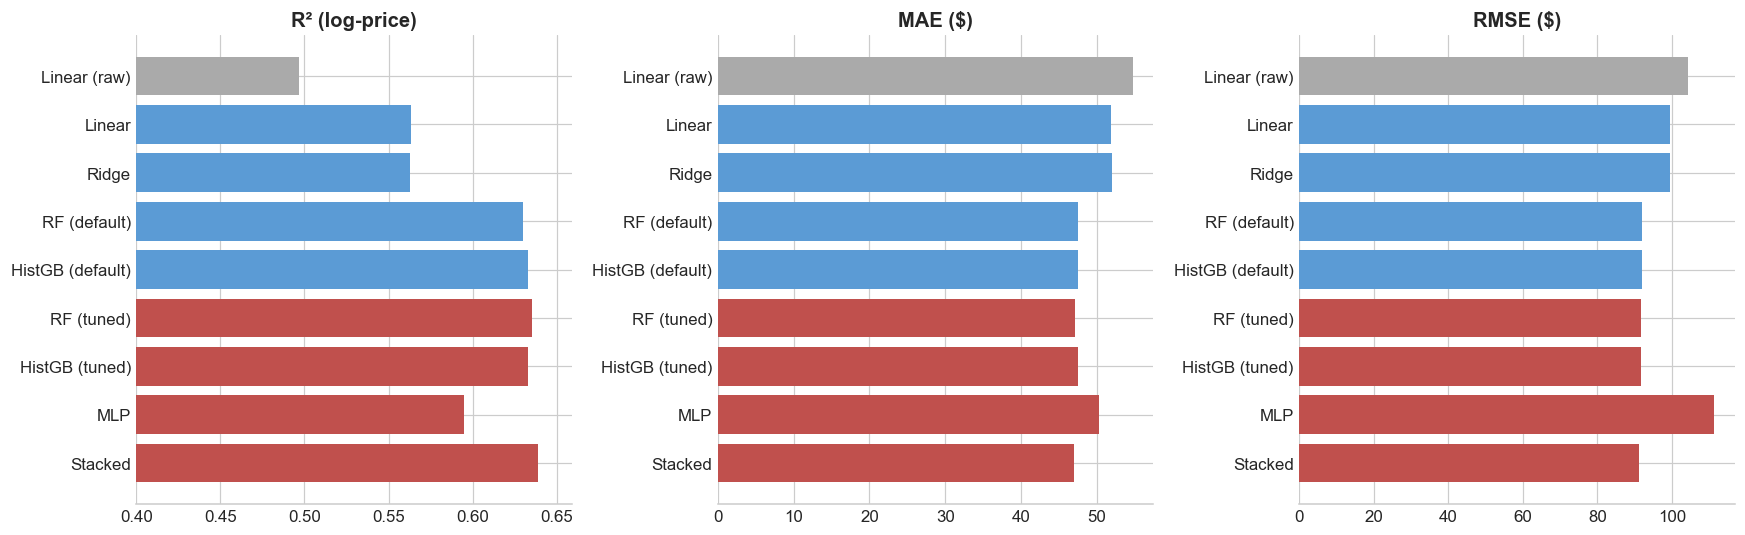

In [ ]:
def fig_model_comparison(items, out=None):
    names = [r[0] for r in items]; colors = [r[2] for r in items]
    r2s = [r[1]['r2_mean'] for r in items]
    maes = [r[1]['mae_mean'] for r in items]
    rmses = [r[1]['rmse_mean'] for r in items]
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    axes[0].barh(names[::-1], r2s[::-1], color=colors[::-1], edgecolor='none')
    axes[0].set_title('R² (log-price)', fontweight='bold'); axes[0].set_xlim(0.4, max(r2s)+0.02)
    axes[1].barh(names[::-1], maes[::-1], color=colors[::-1], edgecolor='none')
    axes[1].set_title('MAE ($)', fontweight='bold')
    axes[2].barh(names[::-1], rmses[::-1], color=colors[::-1], edgecolor='none')
    axes[2].set_title('RMSE ($)', fontweight='bold')
    for ax in axes: sns.despine(ax=ax, left=True)
    plt.tight_layout()
    if out: fig.savefig(out, bbox_inches='tight', dpi=300)
    plt.show()

baseline_for_fig = {
    'rmse_mean': linear_baseline['rmse'], 'rmse_std': 0.0,
    'mae_mean':  linear_baseline['mae'],  'mae_std':  0.0,
    'r2_mean':   linear_baseline['r2_log'], 'r2_std':  0.0,
}
fig_model_comparison([
    ('Linear (raw)',     baseline_for_fig, '#aaaaaa'),
    ('Linear',           cv['linear'],     '#5b9bd5'),
    ('Ridge',            cv['ridge'],      '#5b9bd5'),
    ('RF (default)',     cv['rf_default'], '#5b9bd5'),
    ('HistGB (default)', cv['hgb_default'],'#5b9bd5'),
    ('RF (tuned)',       cv['rf_tuned'],   '#c0504d'),
    ('HistGB (tuned)',   cv['hgb_tuned'],  '#c0504d'),
    ('MLP',              cv['mlp'],        '#c0504d'),
    ('Stacked',          cv['stacked'],    '#c0504d'),
], out=FIG_DIR / 'fig_m3_model_comparison.pdf')


## Held-out test evaluation

Refit each model on the full training set; evaluate on the 20% held-out test.


In [14]:
final_hgb = HistGradientBoostingRegressor(**hgb_params).fit(X_tr, y_tr_log)
final_rf = RandomForestRegressor(**rf_params).fit(X_tr, y_tr_log)

rng = np.random.RandomState(SEED)
perm = rng.permutation(len(X_tr))
cut = int(0.9 * len(X_tr))
sc = StandardScaler().fit(X_tr.values[perm[:cut]])
Xtr_a = sc.transform(X_tr.values[perm[:cut]]).astype(np.float32)
Xva_a = sc.transform(X_tr.values[perm[cut:]]).astype(np.float32)
Xte_a = sc.transform(X_te.values).astype(np.float32)
ytr_a = y_tr_log.values[perm[:cut]].astype(np.float32)
yva_a = y_tr_log.values[perm[cut:]].astype(np.float32)
mlp_final = fit_mlp(Xtr_a, ytr_a, Xva_a, yva_a)
mlp_final.eval()
with torch.no_grad():
    p_mlp_te = mlp_final(torch.tensor(Xte_a, device=DEVICE)).cpu().numpy()
p_hgb_te = final_hgb.predict(X_te); p_rf_te = final_rf.predict(X_te)
p_stack_te = meta.predict(np.column_stack([p_hgb_te, p_rf_te, p_mlp_te]))

def block(p):
    return {'rmse': float(np.sqrt(mean_squared_error(y_te_raw, np.expm1(p)))),
            'mae': float(mean_absolute_error(y_te_raw, np.expm1(p))),
            'r2_log': float(r2_score(y_te_log, p)),
            'r2_raw': float(r2_score(y_te_raw, np.expm1(p)))}
test_results = {'Tuned HistGB': block(p_hgb_te), 'Tuned RF': block(p_rf_te),
                'MLP': block(p_mlp_te), 'Stacked (HGB+RF+MLP)': block(p_stack_te)}
for name, r in test_results.items():
    print(f"{name:25s} R²_log={r['r2_log']:.4f}  MAE=${r['mae']:.2f}  RMSE=${r['rmse']:.2f}")


Tuned HistGB              R²_log=0.6255  MAE=$47.74  RMSE=$93.08
Tuned RF                  R²_log=0.6249  MAE=$47.40  RMSE=$92.96
MLP                       R²_log=0.5800  MAE=$50.79  RMSE=$98.53
Stacked (HGB+RF+MLP)      R²_log=0.6300  MAE=$47.25  RMSE=$92.59


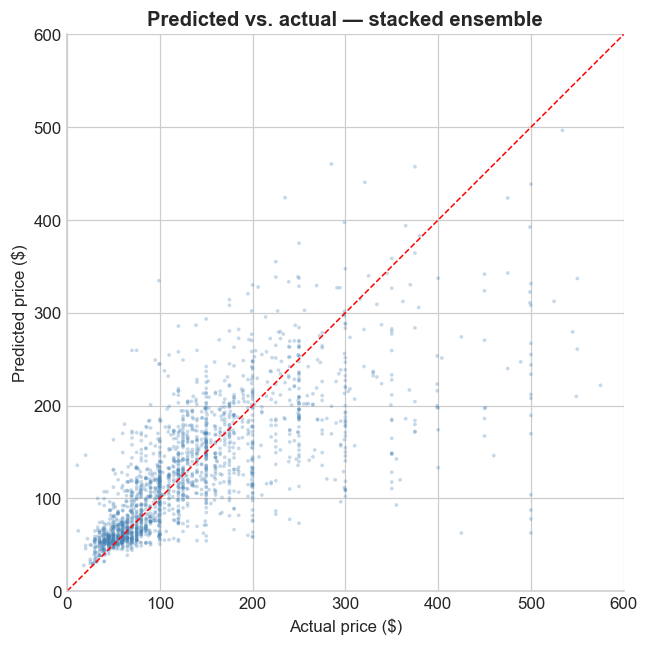

In [15]:
# Predicted vs actual
def fig_pred_vs_actual(y_te_raw, pred_raw, out=None):
    rng = np.random.RandomState(SEED)
    samp = rng.choice(len(y_te_raw), size=min(2000, len(y_te_raw)), replace=False)
    fig, ax = plt.subplots(figsize=(6.5, 6))
    ax.scatter(y_te_raw.values[samp], pred_raw[samp], s=6, alpha=0.3, color='steelblue', edgecolors='none')
    ax.plot([0, 600], [0, 600], color='red', ls='--', lw=1)
    ax.set_xlim(0, 600); ax.set_ylim(0, 600)
    ax.set_xlabel('Actual price ($)'); ax.set_ylabel('Predicted price ($)')
    ax.set_title('Predicted vs. actual — stacked ensemble', fontweight='bold')
    ax.set_aspect('equal'); sns.despine()
    plt.tight_layout()
    if out: fig.savefig(out, bbox_inches='tight', dpi=300)
    plt.show()

fig_pred_vs_actual(y_te_raw, np.expm1(p_stack_te),
                    out=FIG_DIR / 'fig_m3_pred_vs_actual_enriched.pdf')


## SHAP feature attributions

TreeExplainer on the tuned HistGB, evaluated on a 2,000-listing sample of the test set.


                       feature  mean_abs_shap
        room_type_Private room         0.3630
    neighbourhood_median_price         0.1103
              availability_365         0.1037
              dist_times_sq_km         0.0668
                minimum_nights         0.0663
         room_type_Shared room         0.0403
             number_of_reviews         0.0347
                     longitude         0.0307
           tract_median_income         0.0290
               dist_wall_st_km         0.0258
             reviews_per_month         0.0212
                   name_length         0.0200
                   dist_jfk_km         0.0127
   neighbourhood_listing_count         0.0123
calculated_host_listings_count         0.0123


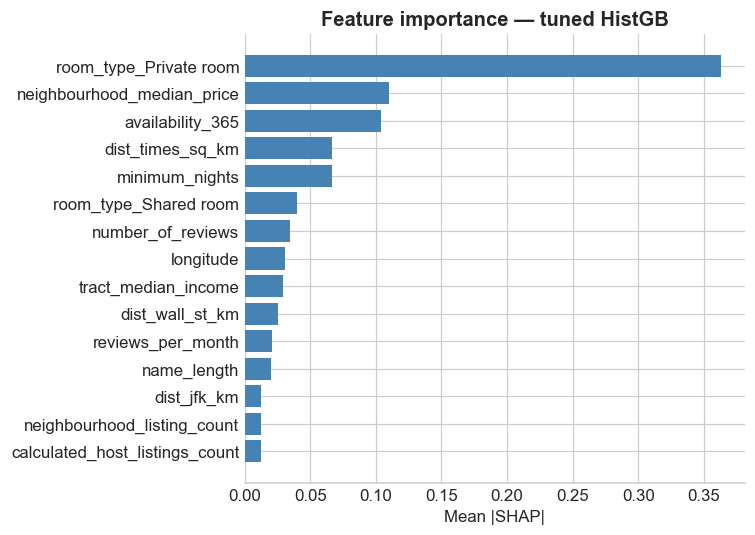

In [ ]:
rng2 = np.random.RandomState(SEED)
sample_idx = rng2.choice(len(X_te), size=min(2000, len(X_te)), replace=False)
explainer = shap.TreeExplainer(final_hgb)
sv = explainer.shap_values(X_te.iloc[sample_idx])
mean_abs = np.abs(sv).mean(axis=0)
shap_top = pd.DataFrame({'feature': feat_names, 'mean_abs_shap': mean_abs}) \
              .sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
print(shap_top.head(15).round(4).to_string(index=False))

def fig_shap_bar(shap_df, out=None):
    df = shap_df.head(15)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.barh(df['feature'][::-1], df['mean_abs_shap'][::-1], color='steelblue', edgecolor='none')
    ax.set_xlabel('Mean |SHAP|')
    ax.set_title('Feature importance — tuned HistGB', fontweight='bold')
    sns.despine(left=True)
    plt.tight_layout()
    if out: fig.savefig(out, bbox_inches='tight', dpi=300)
    plt.show()

fig_shap_bar(shap_top, out=FIG_DIR / 'fig_m3_shap_bar_enriched.pdf')

## External-features removed

Refit the stacked ensemble under cross-validation on a feature matrix without the six external features.

Stacked CV without external: R²=0.6375  MAE=$47.08
Stacked CV with external:    R²=0.6390  MAE=$46.98


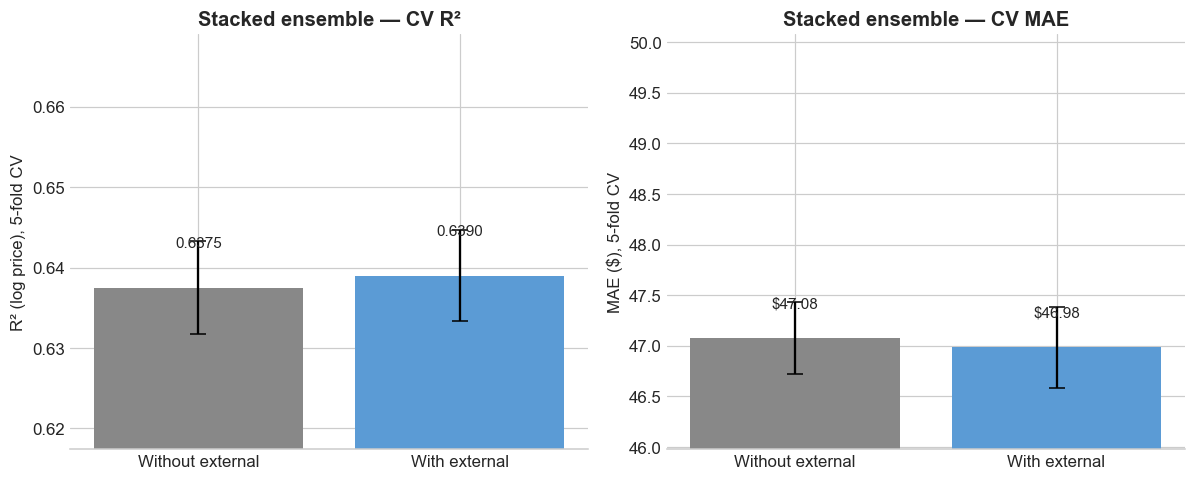

In [ ]:
work_no = df[BASE_NUM + CAT + ['neighbourhood', 'price', 'price_winsor', 'log_price_winsor']].copy()
work_no = pd.get_dummies(work_no, columns=CAT, drop_first=True)
feat_no = [c for c in work_no.columns
           if c not in ['neighbourhood', 'price', 'price_winsor', 'log_price_winsor']]
feat_no = feat_no + ['neighbourhood_median_price']
tr_no = work_no.iloc[train_idx].reset_index(drop=True)
te_no = work_no.iloc[test_idx].reset_index(drop=True)
oof = np.zeros(len(tr_no))
nbh_no = tr_no['neighbourhood'].values; y_raw_no = tr_no['price'].values
for tr_i, va_i in KF.split(tr_no):
    med = pd.Series(y_raw_no[tr_i]).groupby(nbh_no[tr_i]).median()
    overall = float(np.median(y_raw_no[tr_i]))
    oof[va_i] = pd.Series(nbh_no[va_i]).map(med).fillna(overall).values
tr_no['neighbourhood_median_price'] = oof
X_tr_no = tr_no[feat_no].astype(float)

cv_no_ext, _ = stacked_cv(X_tr_no, tr_no['log_price_winsor'], tr_no['price_winsor'],
                            hgb_params, rf_params)
print(f"Stacked CV without external: R²={cv_no_ext['r2_mean']:.4f}  MAE=${cv_no_ext['mae_mean']:.2f}")
print(f"Stacked CV with external:    R²={cv['stacked']['r2_mean']:.4f}  MAE=${cv['stacked']['mae_mean']:.2f}")

def fig_data_eng_comparison(cv_no, cv_yes, out=None):
    stages = ['Without external', 'With external']
    colors = ['#888888', '#5b9bd5']
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    r2 = [cv_no['r2_mean'], cv_yes['r2_mean']]
    r2_std = [cv_no['r2_std'], cv_yes['r2_std']]
    mae = [cv_no['mae_mean'], cv_yes['mae_mean']]
    mae_std = [cv_no['mae_std'], cv_yes['mae_std']]
    axes[0].bar(stages, r2, yerr=r2_std, color=colors, edgecolor='none', capsize=5)
    axes[0].set_ylabel('R² (log price), 5-fold CV')
    axes[0].set_title('Stacked ensemble — CV R²', fontweight='bold')
    for i, v in enumerate(r2):
        axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=10)
    axes[0].set_ylim(min(r2)-0.02, max(r2)+0.03)
    axes[1].bar(stages, mae, yerr=mae_std, color=colors, edgecolor='none', capsize=5)
    axes[1].set_ylabel('MAE ($), 5-fold CV')
    axes[1].set_title('Stacked ensemble — CV MAE', fontweight='bold')
    for i, v in enumerate(mae):
        axes[1].text(i, v + 0.3, f'${v:.2f}', ha='center', fontsize=10)
    axes[1].set_ylim(min(mae)-1, max(mae)+3)
    for ax in axes: sns.despine(ax=ax, left=True)
    plt.tight_layout()
    if out: fig.savefig(out, bbox_inches='tight', dpi=300)
    plt.show()

fig_data_eng_comparison(cv_no_ext, cv['stacked'],
                         out=FIG_DIR / 'fig_m3_data_eng_comparison.pdf')

## Scenario optimization

For three prospective-host scenarios, grid over actionable features (room type, minimum nights, availability, listing-name length) holding static features at the neighborhood's median, and report the predicted-price-maximizing configuration.


              scenario       room_type  minimum_nights  availability_365  name_length  predicted_price
  Entire apt in Harlem Entire home/apt               3               350           80       289.041275
 Spare room in Astoria    Private room               2               350           80       125.927205
Studio in Williamsburg Entire home/apt               2               350           80       402.001091


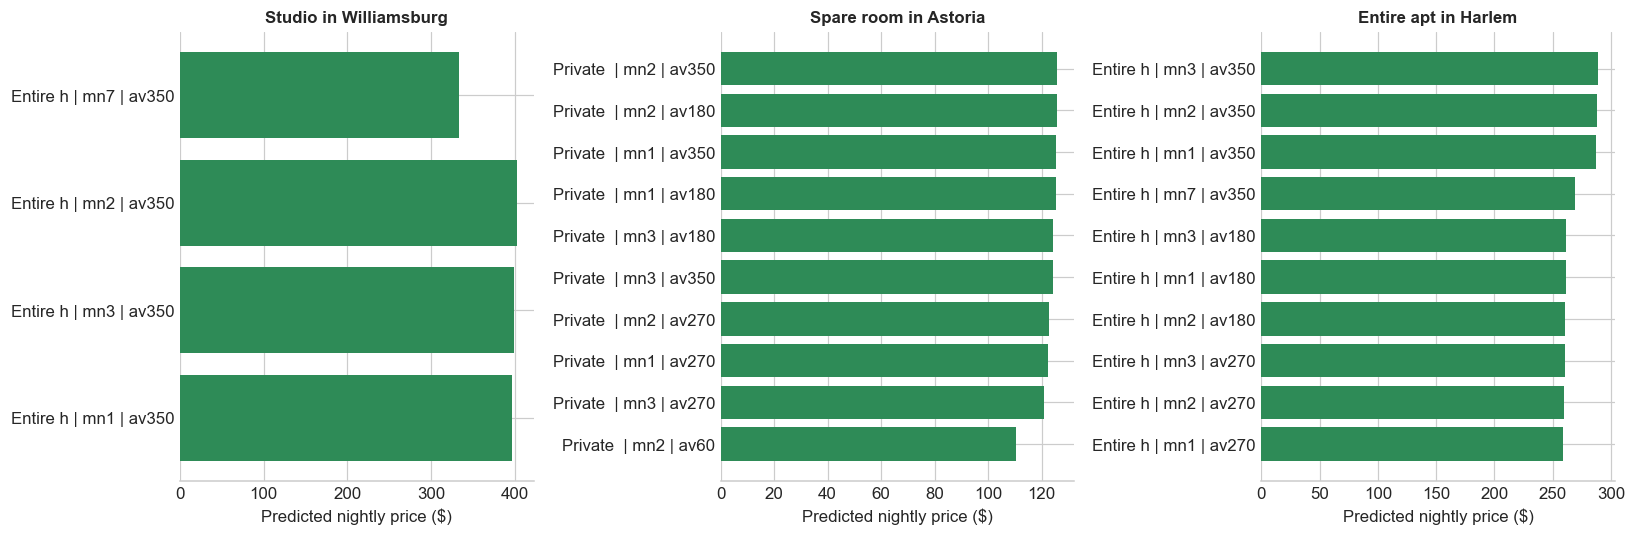

In [ ]:
SCENARIOS = [
    {'name': 'Studio in Williamsburg', 'neighbourhood': 'Williamsburg',
     'neighbourhood_group': 'Brooklyn',
     'room_type_options': ['Entire home/apt', 'Private room']},
    {'name': 'Spare room in Astoria', 'neighbourhood': 'Astoria',
     'neighbourhood_group': 'Queens',
     'room_type_options': ['Private room', 'Shared room']},
    {'name': 'Entire apt in Harlem', 'neighbourhood': 'Harlem',
     'neighbourhood_group': 'Manhattan',
     'room_type_options': ['Entire home/apt']},
]

def scenario_grid(model, df_full, feat_names):
    actionable = {
        'minimum_nights': [1, 2, 3, 7, 30],
        'availability_365': [60, 180, 270, 350],
        'name_length': [25, 50, 80],
    }
    rows = []
    for sc in SCENARIOS:
        nbh_df = df_full[df_full['neighbourhood'] == sc['neighbourhood']]
        if len(nbh_df) == 0: continue
        defaults = {
            'latitude': nbh_df['latitude'].median(),
            'longitude': nbh_df['longitude'].median(),
            'number_of_reviews': 0, 'reviews_per_month': 0,
            'calculated_host_listings_count': 1,
            'dist_times_sq_km': nbh_df['dist_times_sq_km'].median(),
            'host_tenure_days': 0, 'availability_ratio': 0.5,
            'neighbourhood_listing_count': nbh_df['neighbourhood_listing_count'].iloc[0],
            'reviews_per_tenure_day': 0,
            'neighbourhood_median_price': nbh_df['price'].median(),
            'tract_median_income': nbh_df['tract_median_income'].median(),
            'dist_subway_km': nbh_df['dist_subway_km'].median(),
            'dist_central_park_km': nbh_df['dist_central_park_km'].median(),
            'dist_jfk_km': nbh_df['dist_jfk_km'].median(),
            'dist_lga_km': nbh_df['dist_lga_km'].median(),
            'dist_wall_st_km': nbh_df['dist_wall_st_km'].median(),
        }
        for rt in sc['room_type_options']:
            for mn in actionable['minimum_nights']:
                for av in actionable['availability_365']:
                    for nl in actionable['name_length']:
                        row = dict(defaults)
                        row['minimum_nights'] = mn
                        row['availability_365'] = av
                        row['availability_ratio'] = av / 365
                        row['name_length'] = nl
                        for b in ['Brooklyn', 'Manhattan', 'Queens', 'Staten Island']:
                            row[f'neighbourhood_group_{b}'] = float(sc['neighbourhood_group'] == b)
                        for r in ['Private room', 'Shared room']:
                            row[f'room_type_{r}'] = float(rt == r)
                        vec = pd.DataFrame([[row.get(f, 0.0) for f in feat_names]], columns=feat_names)
                        rows.append({
                            'scenario': sc['name'], 'room_type': rt,
                            'minimum_nights': mn, 'availability_365': av, 'name_length': nl,
                            'predicted_price': float(np.expm1(model.predict(vec)[0])),
                        })
    grid = pd.DataFrame(rows)
    best = grid.loc[grid.groupby('scenario')['predicted_price'].idxmax()].reset_index(drop=True)
    return grid, best

df_full = pd.concat([tr, te], ignore_index=True)
grid_df, best_df = scenario_grid(final_hgb, df_full, feat_names)
print(best_df.to_string(index=False))

def fig_scenarios(grid_df, out=None):
    names = grid_df['scenario'].unique().tolist()
    fig, axes = plt.subplots(1, len(names), figsize=(5*len(names), 5))
    if len(names) == 1: axes = [axes]
    for ax, nm in zip(axes, names):
        sub = grid_df[grid_df['scenario']==nm].sort_values('predicted_price', ascending=False).head(10)
        labels = [f'{r.room_type[:8]} | mn{r.minimum_nights} | av{r.availability_365}'
                  for _, r in sub.iterrows()]
        ax.barh(labels[::-1], sub['predicted_price'].values[::-1], color='seagreen', edgecolor='none')
        ax.set_title(nm, fontweight='bold', fontsize=11)
        ax.set_xlabel('Predicted nightly price ($)')
        sns.despine(ax=ax, left=True)
    plt.tight_layout()
    if out: fig.savefig(out, bbox_inches='tight', dpi=300)
    plt.show()

fig_scenarios(grid_df, out=FIG_DIR / 'fig_m3_scenarios_enriched.pdf')